# When does trend work

The 4-week trend book on crypto coins trading at least \$10M a day earns in every full year to 2025 but loses in 2026, and the market version also loses 2020. A strategy that misses the pooled bar can still pass if it clears the bar consistently inside one market condition, a condition that is known before the trade and occurs often enough to matter.

This notebook looks for that condition. Six candidates, each measured only from the past.

- Co-movement. How tightly liquid coins moved together over the last 12 weeks, as their average pairwise correlation.
- Market volatility. The liquid market's weekly volatility over the last 12 weeks.
- Trend strength. The size of the market's last 4-week move measured in its own volatility.
- Funding. Average funding across liquid coins over the last 4 weeks.
- Dispersion. How spread out coins' last 4-week returns are.
- Market direction. Whether the market rose or fell over the last 4 weeks.

Each is cut into low, mid and high thirds. The cut points come only from weeks before the one being sorted, so no week is sorted with future information. Every result is split into the training stretch, 2020 to February 2024, and the unseen stretch after it.

## Setup

Rebuild the two books from the sweep, per coin and market, at 4 weeks on \$10M coins, with the same provisional costs. Then build the six conditions and their thirds.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import panel
import stream

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2})
BLUE, ORANGE, GREY = '#2a78d6', '#eb6834', '#8a8a86'

p = panel.load()
W, R, LIQ, VOL, F = p.weekly, p.simple.fillna(0.0), p.liquidity, p.vol, p.funding
COST = pd.DataFrame(np.where(LIQ >= 1e7, 7.5e-4, 15e-4), index=LIQ.index, columns=LIQ.columns)

def run(w, cost_mult=1.0):
    w = w.fillna(0.0)
    turn = (w - w.shift(1).fillna(0.0)).abs()
    out = pd.DataFrame({'gross': (w * R).sum(axis=1), 'funding': -(w * F).sum(axis=1),
                        'cost': -(turn * COST * cost_mult).sum(axis=1)})
    out['net'] = out.gross + out.funding + out.cost
    return out.loc[(w.abs().sum(axis=1) > 0).idxmax():]

def sharpe(x):
    return x.mean() / x.std() * np.sqrt(52) if len(x) > 2 and x.std() > 0 else np.nan

def sized(sig, floor):
    elig = (LIQ >= floor) & VOL.notna() & (VOL > 0) & sig.notna()
    raw = (sig / VOL).where(elig)
    return raw.div(raw.abs().sum(axis=1), axis=0)

liquid = LIQ >= 1e7
market_ret = W.where(liquid).mean(axis=1)
basket = sized(pd.DataFrame(1.0, index=W.index, columns=W.columns).where(W.shift(1).notna()), 1e7)
per_coin_w = sized(np.sign(W.rolling(4, min_periods=4).sum()).shift(1), 1e7)
market_w = basket.mul(np.sign(market_ret.rolling(4, min_periods=4).sum()).shift(1), axis=0)
per_coin, market, long_basket = run(per_coin_w).net, run(market_w).net, run(basket).net
long_leg, short_leg = run(per_coin_w.clip(lower=0)).net, run(per_coin_w.clip(upper=0)).net

idx = per_coin.index
blocks = np.array_split(np.arange(len(idx)), 5)
train = pd.Series(False, index=idx); train.iloc[np.concatenate(blocks[:3])] = True

Z = (W / VOL).where(liquid)
comove = pd.Series(np.nan, index=W.index)
for i in range(12, len(W)):
    blk = Z.iloc[i - 12:i]
    blk = blk.loc[:, blk.notna().sum() >= 10]
    if blk.shape[1] >= 10:
        c = blk.corr().values; n = c.shape[0]
        comove.iloc[i] = (np.nansum(c) - n) / (n * (n - 1))

cond = pd.DataFrame({
    'co-movement': comove,
    'market vol': market_ret.rolling(12, min_periods=8).std().shift(1),
    'trend strength': (market_ret.rolling(4).sum().abs() / (market_ret.rolling(12, min_periods=8).std() * 2)).shift(1),
    'funding': F.where(liquid).mean(axis=1).rolling(4).mean().shift(1),
    'dispersion': W.where(liquid).rolling(4, min_periods=4).sum().std(axis=1).shift(1),
    'market direction': np.sign(market_ret.rolling(4).sum()).shift(1)})

def thirds(x, min_hist=52):
    out = pd.Series(np.nan, index=x.index)
    for i in range(len(x)):
        past = x.iloc[:i].dropna()
        if len(past) >= min_hist and not np.isnan(x.iloc[i]):
            lo, hi = past.quantile([1 / 3, 2 / 3])
            out.iloc[i] = 0 if x.iloc[i] <= lo else (2 if x.iloc[i] > hi else 1)
    return out

labels = {k: (thirds(v) if k != 'market direction' else v.map({-1.0: 0, 1.0: 2})).reindex(idx) for k, v in cond.items()}
BUCKET = {0: 'low', 1: 'mid', 2: 'high'}
print('median of each condition by year')
print(cond.groupby(cond.index.year).median().round(3).T)

median of each condition by year
day                2020   2021   2022   2023   2024   2025   2026
co-movement       0.486  0.495  0.660  0.628  0.585  0.673  0.462
market vol        0.095  0.135  0.122  0.095  0.115  0.123  0.075
trend strength    0.883  0.879  0.851  0.666  0.619  0.905  0.960
funding           0.002  0.005 -0.001  0.001  0.001 -0.002 -0.007
dispersion        0.174  0.313  0.164  0.148  0.202  0.258  0.401
market direction  1.000  1.000 -1.000  1.000 -1.000 -1.000 -1.000


2026 is unlike any earlier year. It has the lowest co-movement, 0.46, the lowest market volatility, 0.075 a week, and the highest dispersion, 0.40. Coins stopped moving as a pack, the market went quiet, and individual coins scattered.

Market direction here is the median of $+1$ or $-1$, so it only says whether most weeks followed a rise or a fall.

## The map

Net Sharpe of the per coin book in each third of each condition, over all weeks, the training weeks and the unseen weeks, with the share of weeks each third holds. A condition is only interesting if training and unseen agree.

per coin, all weeks   0.85   train 1.04   unseen 0.55
                         all  train  unseen  share of weeks
condition        third                                     
co-movement      low    0.92   0.27    1.22            0.23
                 mid   -0.01  -0.10    0.05            0.29
                 high   1.14   1.42    0.58            0.29
market vol       low    0.56   0.23    0.87            0.35
                 mid    0.67   0.57    0.83            0.28
                 high   0.59   1.22   -0.06            0.21
trend strength   low    1.61   1.21    2.17            0.29
                 mid    0.56   0.81    0.25            0.29
                 high   0.02   0.06   -0.01            0.26
funding          low    0.07   0.21   -0.06            0.45
                 mid    0.78   0.84    0.64            0.29
                 high   1.94   1.44    2.60            0.12
dispersion       low    0.46   0.46    0.47            0.24
                 mid    1.03   1.51    0.39   

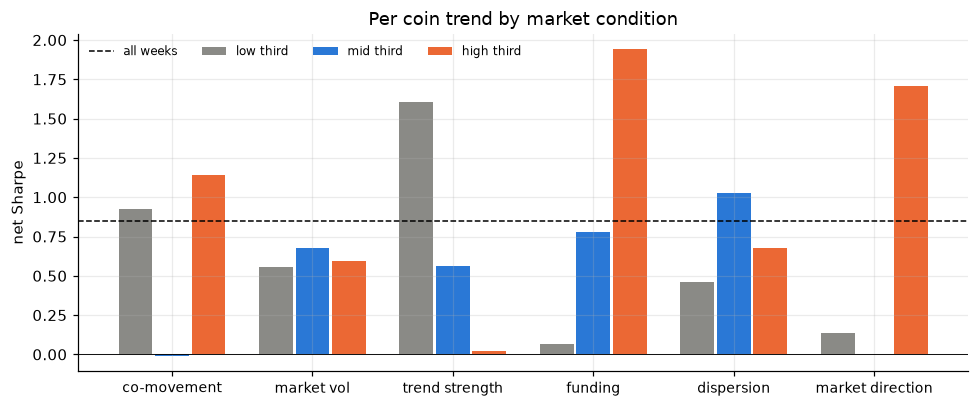

In [2]:
def cond_map(net):
    rows = []
    for k, lab in labels.items():
        for v in [0, 1, 2]:
            m = lab == v
            if m.sum() == 0:
                continue
            rows.append({'condition': k, 'third': BUCKET[v], 'all': sharpe(net[m]), 'train': sharpe(net[m & train]),
                         'unseen': sharpe(net[m & ~train]), 'share of weeks': m.mean()})
    return pd.DataFrame(rows).set_index(['condition', 'third'])

print(f'per coin, all weeks   {sharpe(per_coin):.2f}   train {sharpe(per_coin[train]):.2f}   unseen {sharpe(per_coin[~train]):.2f}')
print(cond_map(per_coin).round(2))
print()
print(f'market book, all weeks   {sharpe(market):.2f}   train {sharpe(market[train]):.2f}   unseen {sharpe(market[~train]):.2f}')
print(cond_map(market).round(2))

cm = cond_map(per_coin)
fig, ax = plt.subplots(figsize=(9, 3.8))
conds = list(labels)
x = np.arange(len(conds)); wd = 0.26
for i, (t, colour) in enumerate([('low', GREY), ('mid', BLUE), ('high', ORANGE)]):
    vals = [cm.loc[(c, t), 'all'] if (c, t) in cm.index else np.nan for c in conds]
    ax.bar(x + (i - 1) * wd, vals, width=wd - 0.02, color=colour, label=f'{t} third')
ax.axhline(sharpe(per_coin), color='k', ls='--', lw=1, label='all weeks')
ax.axhline(0, color='k', lw=0.6)
ax.set_xticks(x); ax.set_xticklabels(conds, fontsize=9); ax.set_ylabel('net Sharpe')
ax.set_title('Per coin trend by market condition'); ax.legend(frameon=False, ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

Two conditions agree between training and unseen weeks, in both books.

- Market direction. After the market rose over the last 4 weeks, per coin trend makes 1.71, with 1.87 in training and 1.29 unseen. After it fell, 0.13.
- Trend strength. When the market's last 4-week move was small against its volatility, per coin trend makes 1.61, with 1.21 in training and 2.17 unseen. After a large move, 0.02.

High funding scores 1.94 but holds only 12% of weeks. The rest disagree between training and unseen or change little across thirds. Low co-movement, the obvious suspect for 2026, is weak in training at 0.27 and strong unseen at 1.22.

This map is 34 cells across two books, so single cells need the same caution as any grid.

## Is it trend, or just being long

After a rise, the book is mostly long, so its profit there could simply be crypto rising. Compare the same weeks with holding the basket long, and split the book into its long and short sides. Do the same for trend strength.

In [3]:
direction, strength = labels['market direction'], labels['trend strength']
rows = []
for name, m in [('after a rise', direction == 2), ('after a fall', direction == 0),
                ('trend strength low', strength == 0), ('trend strength mid', strength == 1), ('trend strength high', strength == 2)]:
    rows.append({'weeks': name, 'per coin': sharpe(per_coin[m]), 'long basket': sharpe(long_basket[m]),
                 'long side': sharpe(long_leg[m]), 'short side': sharpe(short_leg[m]), 'count': int(m.sum())})
print(pd.DataFrame(rows).set_index('weeks').round(2))
print()
print('direction by strength, per coin net Sharpe and share of weeks')
print(pd.DataFrame({d: {BUCKET[v]: f'{sharpe(per_coin[(direction == dv) & (strength == v)]):+.2f} ({((direction == dv) & (strength == v)).mean():.0%})'
                        for v in [0, 1, 2]} for d, dv in [('after a rise', 2), ('after a fall', 0)]}).T)

                     per coin  long basket  long side  short side  count
weeks                                                                   
after a rise             1.71         1.54       1.71       -0.62    146
after a fall             0.13        -0.22      -0.20        0.18    190
trend strength low       1.61        -0.91      -0.26        1.36     98
trend strength mid       0.56         0.84       1.27       -0.28     98
trend strength high      0.02         0.74       0.63       -0.51     88

direction by strength, per coin net Sharpe and share of weeks
                      low          mid         high
after a rise  +1.19 (15%)   +2.58 (9%)   +0.78 (9%)
after a fall  +2.02 (14%)  -0.27 (21%)  -0.45 (17%)


After a rise, holding the basket long makes 1.54, almost as much as trend's 1.71. The long side makes 1.71 and the short side loses $-0.62$. So this condition is mostly rallies continuing, and being long captures it. After a fall, the short side earns only 0.18. Rises continue, falls barely do. That matches the tails, where big moves lean up.

Trend strength is different. When the last month's move was small, holding the basket loses $-0.91$ while trend makes 1.61, and the profit comes from the short side at 1.36. Small declines keep going, and the signal is doing the work. A large move tends to be overextended and trend earns nothing after one.

The best combinations are a small fall, 2.02 over 14% of weeks, and a rise of middling strength, 2.58 over 9%. Middling and large falls lose.

## Year by year inside the condition

A conditional pass needs the condition to work consistently. Split the per coin book's weeks inside each condition by year. Then trade only inside the condition and sit flat otherwise, and read that book by year.

In [4]:
inside = {}
for name, m in [('after a rise', direction == 2), ('trend strength low', strength == 0), ('all weeks', pd.Series(True, index=idx))]:
    x = per_coin[m]
    inside[name] = {y: f'{sharpe(g):+.2f} ({len(g)})' for y, g in x.groupby(x.index.year)}
print('net Sharpe inside the condition by year (weeks)')
print(pd.DataFrame(inside).T)
print()
for name, m in [('after a rise', direction == 2), ('trend strength low', strength == 0)]:
    g = run(per_coin_w.where(m.reindex(per_coin_w.index).fillna(False).astype(bool), 0.0)).net
    print(f'{name:19} traded only inside   Sharpe {sharpe(g):+.2f}   return {g.mean() * 5200:+.1f}% a year   by year',
          {y: round(sharpe(v), 2) for y, v in g.groupby(g.index.year)})
print(f'{"always on":19}                      Sharpe {sharpe(per_coin):+.2f}   return {per_coin.mean() * 5200:+.1f}% a year')

net Sharpe inside the condition by year (weeks)
                          2020        2021        2022        2023  \
after a rise        +1.43 (24)  +3.32 (35)  -1.05 (14)  +2.34 (27)   
trend strength low         NaN  +1.96 (15)  +3.30 (18)  +0.12 (18)   
all weeks           +1.06 (39)  +1.69 (52)  +0.79 (52)  +0.82 (53)   

                          2024        2025        2026  
after a rise        +1.51 (25)  +1.10 (12)   -1.19 (9)  
trend strength low  +1.16 (22)  +3.70 (15)  +1.01 (10)  
all weeks           +0.25 (52)  +1.15 (52)  -0.64 (36)  



after a rise        traded only inside   Sharpe +1.10   return +41.0% a year   by year {2020: np.float64(1.14), 2021: np.float64(2.63), 2022: np.float64(-0.57), 2023: np.float64(1.63), 2024: np.float64(1.03), 2025: np.float64(0.54), 2026: np.float64(-0.63)}


trend strength low  traded only inside   Sharpe +0.90   return +19.9% a year   by year {2021: np.float64(1.26), 2022: np.float64(1.78), 2023: np.float64(0.03), 2024: np.float64(0.73), 2025: np.float64(1.82), 2026: np.float64(0.53)}
always on                                Sharpe +0.85   return +44.9% a year


After a rise is not consistent. It loses in 2022 and 2026.

Low trend strength is. It is positive in every year it covers, 2021 to 2026, though near flat in 2023 at 0.12. 2020 has no label because the cut points need a year of history first.

Trading only after a rise lifts the Sharpe from 0.85 to 1.10 at nearly the same return, because it drops the weeks that earned little. Trading only when trend strength is low makes 0.90 and is positive every year, but earns far less, 20% a year against 45%, since it sits out most weeks.

## Can any condition rescue 2026

Sort just the 2026 weeks into the same thirds.

In [5]:
in_2026 = idx.year == 2026
rows = {}
for k, lab in labels.items():
    rows[k] = {BUCKET[v]: f'{sharpe(per_coin[in_2026 & (lab == v)]):+.2f} ({int((in_2026 & (lab == v)).sum())})'
               for v in [0, 1, 2] if (in_2026 & (lab == v)).sum() > 1}
print('2026 only, per coin net Sharpe by third (weeks)')
print(pd.DataFrame(rows).T.fillna(''))
print(f'2026 mean weekly net {per_coin[in_2026].mean() * 1e4:+.1f} bps   worst week {per_coin[in_2026].min():+.3f}')

2026 only, per coin net Sharpe by third (weeks)
                         low         mid        high
co-movement       -0.64 (36)                        
market vol        -0.64 (36)                        
trend strength    +1.01 (10)  -0.18 (10)  -1.85 (16)
funding           -0.57 (32)   -0.96 (4)            
dispersion                                -0.17 (35)
market direction  -0.40 (27)               -1.19 (9)
2026 mean weekly net -42.7 bps   worst week -0.117


All 36 weeks of 2026 fall in the lowest third of co-movement and of market volatility, and 35 of them in the highest third of dispersion. Those conditions put all of 2026 in one corner, so they cannot separate it.

Trend strength does. The 2026 weeks after a small move made 1.01, those after a middling move $-0.18$ and those after a large move $-1.85$. The year's loss came from weeks after big market moves. The book lost 43 bps a week on average in 2026, with a worst week of $-11.7\%$.

## Open interest

Open interest is the total size of open perp positions, a direct read on leverage. The forced deleveraging idea says trend feeds on leverage, since liquidations push price further in the direction it is already moving.

Open interest in dollars rises just because price rises, so measure it in contracts instead, dollar open interest over price, summed across BTC, ETH, SOL, BNB, XRP and DOGE. Two conditions, both from past weeks only. Its growth over the last 4 weeks, and its level against its own 26-week average, each cut into thirds on earlier weeks.

In [6]:
majors = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT']
oi = stream.open_interest(majors, '2020-09-01', '2026-09-01')
print('coverage from', {s: str(oi[s].first_valid_index().date()) for s in majors})
log_oi = np.log(oi.resample('W-SUN').last().reindex(W.index))
log_contracts = log_oi.sub(W[majors].cumsum(), axis=0)
oi_cond = {'OI growth, 4 weeks': log_contracts.diff(4).mean(axis=1).shift(1),
           'OI level vs 26-week average': (log_contracts - log_contracts.rolling(26, min_periods=13).mean()).mean(axis=1).shift(1)}
rows = []
for k, v in oi_cond.items():
    lab = thirds(v).reindex(idx)
    for t in [0, 1, 2]:
        m = lab == t
        rows.append({'condition': k, 'third': BUCKET[t], 'all': sharpe(per_coin[m]), 'train': sharpe(per_coin[m & train]),
                     'unseen': sharpe(per_coin[m & ~train]), 'weeks': int(m.sum())})
print(pd.DataFrame(rows).set_index(['condition', 'third']).round(2))
print()
print('correlation with the other conditions')
print(pd.DataFrame({**oi_cond, 'trend strength': cond['trend strength'], 'market direction': cond['market direction']}).corr().round(2))

coverage from {'BTCUSDT': '2020-09-01', 'ETHUSDT': '2021-12-01', 'SOLUSDT': '2021-12-01', 'BNBUSDT': '2021-12-01', 'XRPUSDT': '2021-12-01', 'DOGEUSDT': '2021-12-01'}


                                    all  train  unseen  weeks
condition                   third                            
OI growth, 4 weeks          low   -0.12  -0.89    0.36     52
                            mid    1.04   0.86    1.11     99
                            high   0.52   2.30   -0.17     57
OI level vs 26-week average low   -1.39  -1.82   -1.25     57
                            mid    1.68   1.08    2.02     70
                            high   0.84   1.12    0.77     64

correlation with the other conditions
                             OI growth, 4 weeks  OI level vs 26-week average  \
OI growth, 4 weeks                         1.00                         0.64   
OI level vs 26-week average                0.64                         1.00   
trend strength                            -0.27                        -0.21   
market direction                           0.22                         0.16   

                             trend strength  market direction  


Growth in open interest says nothing reliable. Its thirds disagree between training and unseen weeks.

Its level does. When open interest sits below its recent average, after the market has shed leverage, trend loses, $-1.39$ over all weeks, $-1.82$ in training and $-1.25$ unseen. At middling and high levels it earns, 1.68 and 0.84. That fits the leverage idea from the other side. Trend needs leverage in the market to feed its moves.

The evidence is thin. Open interest for five of the six majors starts in December 2021, and the thirds need a year of history, so the labels cover about 190 weeks from late 2022, around 60 per third. It is only loosely tied to trend strength, a correlation of $-0.21$, so it carries mostly separate information.

## Is low trend strength robust

It was found by looking, so shake it. Move the cut point to a quarter and a half. Measure the move over 2, 4 and 8 weeks and the volatility over 8, 12 and 26. Apply it to the other lookbacks of the per coin book. Shorten the warm-up so 2020 gets labels. Rerun at twice cost.

In [7]:
def small_move(n_ret=4, n_vol=12, q=1 / 3, min_hist=52):
    x = (market_ret.rolling(n_ret).sum().abs() / (market_ret.rolling(n_vol, min_periods=8).std() * np.sqrt(n_ret))).shift(1)
    out = pd.Series(np.nan, index=x.index)
    for i in range(len(x)):
        past = x.iloc[:i].dropna()
        if len(past) >= min_hist and not np.isnan(x.iloc[i]):
            out.iloc[i] = float(x.iloc[i] <= past.quantile(q))
    return out.reindex(idx)

def years_positive(m):
    y = per_coin[m].groupby(per_coin[m].index.year).apply(sharpe).dropna()
    return f'{int((y > 0).sum())} of {len(y)}'

rows = []
for q in [0.25, 1 / 3, 0.5]:
    m = small_move(q=q) == 1
    rows.append({'variant': f'cut at {q:.0%}', 'inside': sharpe(per_coin[m]), 'train': sharpe(per_coin[m & train]),
                 'unseen': sharpe(per_coin[m & ~train]), 'years positive': years_positive(m), 'weeks': m.mean()})
for nr in [2, 4, 8]:
    for nv in [8, 12, 26]:
        m = small_move(nr, nv) == 1
        rows.append({'variant': f'{nr}w move, {nv}w vol', 'inside': sharpe(per_coin[m]), 'train': sharpe(per_coin[m & train]),
                     'unseen': sharpe(per_coin[m & ~train]), 'years positive': years_positive(m), 'weeks': m.mean()})
print(pd.DataFrame(rows).set_index('variant').round(2))
print()

base = small_move() == 1
labelled = small_move().notna()
for L in [1, 2, 4, 8, 12]:
    nL = run(sized(np.sign(W.rolling(L, min_periods=L).sum()).shift(1), 1e7)).net.reindex(idx)
    print(f'per coin L={L:2d}   inside {sharpe(nL[base]):+.2f}   outside {sharpe(nL[~base & labelled]):+.2f}')
print(f'market L= 4   inside {sharpe(market[base]):+.2f}   outside {sharpe(market[~base & labelled]):+.2f}')
print()
early = small_move(min_hist=26) == 1
print('26-week warm-up, by year', {y: f'{sharpe(g):+.2f} ({len(g)})' for y, g in per_coin[early].groupby(per_coin[early].index.year)})
print(f'inside at twice cost {sharpe(run(per_coin_w, 2.0).net[base]):+.2f}')

                  inside  train  unseen years positive  weeks
variant                                                      
cut at 25%          1.18   0.88    1.68         5 of 6   0.21
cut at 33%          1.61   1.21    2.17         6 of 6   0.29
cut at 50%          0.76   0.43    1.17         5 of 6   0.43
2w move, 8w vol     1.57   1.68    1.42         6 of 6   0.25
2w move, 12w vol    1.98   1.99    1.95         6 of 6   0.24
2w move, 26w vol    2.71   2.99    2.28         6 of 6   0.23
4w move, 8w vol     1.45   1.07    1.91         6 of 6   0.30
4w move, 12w vol    1.61   1.21    2.17         6 of 6   0.29
4w move, 26w vol    1.44   1.08    1.99         6 of 6   0.29
8w move, 8w vol     1.01   0.85    1.23         5 of 6   0.33
8w move, 12w vol    1.29   1.19    1.42         5 of 6   0.33
8w move, 26w vol    1.17   1.19    1.12         3 of 6   0.30



per coin L= 1   inside +1.75   outside -0.39
per coin L= 2   inside +0.93   outside -0.45
per coin L= 4   inside +1.61   outside +0.29
per coin L= 8   inside +0.67   outside -0.10
per coin L=12   inside +0.53   outside -0.19
market L= 4   inside +1.65   outside +0.12



26-week warm-up, by year {2020: '+6.18 (7)', 2021: '+2.24 (18)', 2022: '+3.30 (18)', 2023: '+0.12 (18)', 2024: '+1.16 (22)', 2025: '+3.70 (15)', 2026: '+1.01 (10)'}
inside at twice cost +1.53


The window barely matters. Every 2 and 4 week move with every volatility window stays positive in all six years, at 1.42 to 2.28 unseen. An 8 week move weakens it.

Inside the condition, per coin trend earns at every lookback, from 0.53 to 1.75. Outside it, per coin trend loses at every lookback except 4 weeks, which keeps 0.29. The market book makes 1.65 inside and 0.12 outside. This condition marks where trend lives.

With a shorter warm-up, 2020 is labelled and positive too. At twice cost the inside Sharpe is 1.53.

The weak spot is the cut point. Thirds work best. A quarter loses 2024 and a half loses 2021, though both stay positive overall and unseen.

## Against the conditional bar

The condition is known at trade time, since the move and its volatility come from past weeks and the cut point from earlier weeks. It holds 29% of weeks. Check the book inside it against the bar, and correct for luck using every trial run so far, 45 in the sweep and its history plus 34 map cells and about 15 robustness variants.

In [8]:
from scipy import stats

x = per_coin[base]
yrs = x.groupby(x.index.year).sum()
drag = run(per_coin_w)
drag = drag[base.reindex(drag.index).fillna(False).astype(bool)]
print(f'inside Sharpe {sharpe(x):.2f}   unseen {sharpe(x[~train[base]]):.2f}   years positive {int((yrs > 0).sum())} of {len(yrs)}')
print(f'2022 bear {sharpe(x.loc["2022"]):.2f}   twice cost {sharpe(run(per_coin_w, 2.0).net[base]):.2f}   '
      f'cost + funding share of gross {-(drag.cost.sum() + drag.funding.sum()) / drag.gross.sum():.0%}')

cm = pd.concat([cond_map(per_coin), cond_map(market)])
spread = (cm['all'] / np.sqrt(52)).std()
sr, T = x.mean() / x.std(), len(x)
sk, ku = stats.skew(x), stats.kurtosis(x, fisher=False)
g = 0.5772156649
for trials in [45, 95]:
    bar = spread * ((1 - g) * stats.norm.ppf(1 - 1 / trials) + g * stats.norm.ppf(1 - 1 / (trials * np.e)))
    prob = stats.norm.cdf((sr - bar) * np.sqrt(T - 1) / np.sqrt(1 - sk * sr + (ku - 1) / 4 * sr ** 2))
    print(f'{trials} trials   luck bar {bar * np.sqrt(52):.2f}   probability real {prob:.2f}   over {T} weeks')

inside Sharpe 1.61   unseen 2.17   years positive 6 of 6
2022 bear 3.30   twice cost 1.53   cost + funding share of gross 5%
45 trials   luck bar 1.35   probability real 0.64   over 98 weeks
95 trials   luck bar 1.52   probability real 0.55   over 98 weeks


## Sleeve against always-on book

The Sharpe just above is the sleeve, the record over the weeks the condition holds. That is what runs live, since a regime detector switches the signal on and off, so the sleeve is where the signal is judged.

Set it against the same rule run across the whole calendar, flat only where the condition is off. That book earns less and its odds against the luck bar collapse. The gap is not a second verdict on the signal, it is the cost of leaving it always on, the job a regime gate removes.

In [9]:
gated_w = per_coin_w.where(base.reindex(per_coin_w.index).fillna(False), 0.0)
gated = run(gated_w).net
tr = train.reindex(gated.index).fillna(False)

def deflated(s, trials):
    sr, T = s.mean() / s.std(), len(s)
    sk, ku = stats.skew(s), stats.kurtosis(s, fisher=False)
    g = 0.5772156649
    bar = spread * ((1 - g) * stats.norm.ppf(1 - 1 / trials) + g * stats.norm.ppf(1 - 1 / (trials * np.e)))
    prob = stats.norm.cdf((sr - bar) * np.sqrt(T - 1) / np.sqrt(1 - sk * sr + (ku - 1) / 4 * sr ** 2))
    return bar * np.sqrt(52), prob

yrs = gated.groupby(gated.index.year).sum()
print(f'sleeve, {int(base.sum())} condition weeks only   Sharpe {sharpe(per_coin[base]):.2f}   unseen {sharpe(per_coin[base & ~train]):.2f}')
print(f'always-on book, flat when off         Sharpe {sharpe(gated):.2f}   unseen {sharpe(gated[~tr]):.2f}   '
      f'years positive {int((yrs > 0).sum())} of {len(yrs)}   twice cost {sharpe(run(gated_w, 2.0).net):.2f}')
print()
for name, s in [('sleeve', per_coin[base]), ('always-on book', gated)]:
    for trials in [45, 95]:
        bar, prob = deflated(s, trials)
        print(f'{name:16s} {trials} trials   luck bar {bar:.2f}   probability real {prob:.2f}')


sleeve, 98 condition weeks only   Sharpe 1.61   unseen 2.17
always-on book, flat when off         Sharpe 0.90   unseen 1.19   years positive 6 of 6   twice cost 0.82

sleeve           45 trials   luck bar 1.35   probability real 0.64
sleeve           95 trials   luck bar 1.52   probability real 0.55
always-on book   45 trials   luck bar 1.35   probability real 0.13
always-on book   95 trials   luck bar 1.52   probability real 0.06


The sleeve reads real at even odds, 0.55 to 0.64, on 98 weeks. The always-on book earns 0.90 over the full span, positive in every year and 0.82 at twice cost, but its odds against the same luck bar fall to 0.06 to 0.13.

That collapse is the cost of running the signal all the time, not a mark against the signal. A regime gate would trade only the sleeve. What the sleeve cannot escape is its own sample, the edge sits in 98 weeks and no window or cut adds more.

## Verdict

A candidate, under-powered. Per coin trend works after a moderate market month, when the market's last 4-week move was small against its volatility. Inside that condition it makes 1.61, 2.17 on unseen weeks, positive in every year from 2020 to 2026 and holding at twice cost. The profit comes from shorting coins that keep drifting down after a small market decline.

That sleeve is the object a live book would trade, since a regime detector owns the on and off. Judge it there, not on the always-on book. After correcting for the roughly 95 configurations tried, its odds of being real are 0.55 to 0.64, even money on 98 weeks.

So it is not thrown out and not banked. The binding constraint is the 98 weeks, and no window or cut fixes it. The cut point already matters more than it should, thirds best, a quarter or a half weaker. Park it for more weeks or a mechanism that raises the prior and cuts the penalty for finding it by looking.

After a rise is the other strong condition, but it is mostly being long in a rally and it loses in 2022 and 2026.

Open interest adds a separate warning on the same side. Trend loses when open interest in contracts sits below its recent average, in training and unseen weeks alike, on only about 190 weeks of history.